In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
BASE_PATH = "/content/drive/MyDrive/mind-recommender/data"
RESULTS_PATH = "/content/drive/MyDrive/mind-recommender/results"

os.makedirs(RESULTS_PATH, exist_ok=True)

news_cols = ['news_id', 'category', 'subcategory', 'title',
             'abstract', 'url', 'title_entities', 'abstract_entities']

beh_cols = ['impression_id', 'user_id', 'time', 'history', 'impressions']

train_news = pd.read_csv(
    f"{BASE_PATH}/MINDsmall_train/news.tsv",
    sep='\t',
    names=news_cols
)

train_behaviors = pd.read_csv(
    f"{BASE_PATH}/MINDsmall_train/behaviors.tsv",
    sep='\t',
    names=beh_cols
)

print("Train news shape:", train_news.shape)
print("Train behaviors shape:", train_behaviors.shape)

display(train_news.head())
display(train_behaviors.head())

Train news shape: (51282, 8)
Train behaviors shape: (156965, 5)


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


,impression_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...
3,4,U34670,11/11/2019 5:28:05 AM,N45729 N2203 N871 N53880 N41375 N43142 N33013 ...,N35729-0 N33632-0 N49685-1 N27581-0
4,5,U8125,11/12/2019 4:11:21 PM,N10078 N56514 N14904 N33740,N39985-0 N36050-0 N16096-0 N8400-1 N22407-0 N6...


In [4]:
def count_clicks(imp_str):
    if pd.isna(imp_str):
        return 0
    return sum(1 for x in str(imp_str).split() if x.endswith('-1'))

def count_candidates(imp_str):
    if pd.isna(imp_str):
        return 0
    return len(str(imp_str).split())

def history_length(hist_str):
    if pd.isna(hist_str):
        return 0
    return len(str(hist_str).split())

train_behaviors['n_clicks'] = train_behaviors['impressions'].apply(count_clicks)
train_behaviors['impression_size'] = train_behaviors['impressions'].apply(count_candidates)
train_behaviors['history_len'] = train_behaviors['history'].apply(history_length)

train_behaviors['time'] = pd.to_datetime(train_behaviors['time'], errors='coerce')
train_behaviors['hour'] = train_behaviors['time'].dt.hour
train_behaviors['date'] = train_behaviors['time'].dt.date

train_news['title_len'] = train_news['title'].fillna('').apply(lambda x: len(str(x).split()))
train_news['abstract_len'] = train_news['abstract'].fillna('').apply(lambda x: len(str(x).split()))

Total news articles: 51282
Total users: 50000
Total impressions: 156965
Total clicks: 236344
Overall CTR: 0.0404


The dataset contains 51,282 news articles, 50,000 users, and 156,965 impressions, indicating a large-scale interaction dataset suitable for recommendation modeling. The overall click-through rate (CTR) is approximately 4.04%, which is relatively low, suggesting that users only engage with a small fraction of displayed articles. Such a low CTR reflects the inherent difficulty of the recommendation task, where relevant content must be accurately identified from a large pool of candidates.This highlights the importance of building an effective recommendation system to surface relevant content and improve user engagement.


In [23]:
rows = []

for _, row in train_behaviors.iterrows():
    if pd.isna(row['impressions']):
        continue
    for item in str(row['impressions']).split():
        news_id, label = item.split('-')
        rows.append((news_id, int(label)))

click_df = pd.DataFrame(rows, columns=['news_id', 'clicked'])

click_news = click_df.merge(
    train_news[['news_id', 'category', 'subcategory']],
    on='news_id',
    how='left'
)

display(click_news.head())

,news_id,clicked,category,subcategory
0,N55689,1,sports,football_nfl
1,N35729,0,news,newsus
2,N20678,0,sports,more_sports
3,N39317,0,news,newspolitics
4,N58114,0,autos,autosnews


The click data was merged with the news dataset using news_id to attach category and subcategory information to each interaction. This enables analysis of user engagement across different content types and supports category-level insights for recommendation modeling.

In [32]:
print("Missing values in train_news:")
display(train_news.isnull().sum())

print("Missing values in train_behaviors:")
display(train_behaviors.isnull().sum())

Missing values in train_news:


,0
news_id,0
category,0
subcategory,0
title,0
abstract,2666
url,0
title_entities,3
abstract_entities,4
title_len,0
abstract_len,0


Missing values in train_behaviors:


,0
impression_id,0
user_id,0
time,0
history,3238
impressions,0
n_clicks,0
impression_size,0
history_len,0
hour,0
date,0


The dataset is relatively clean, with missing values concentrated primarily in the abstract and history fields. While the missing abstracts may slightly reduce the effectiveness of text-based models, the presence of cold-start users is a more critical challenge that must be addressed in recommendation system design.

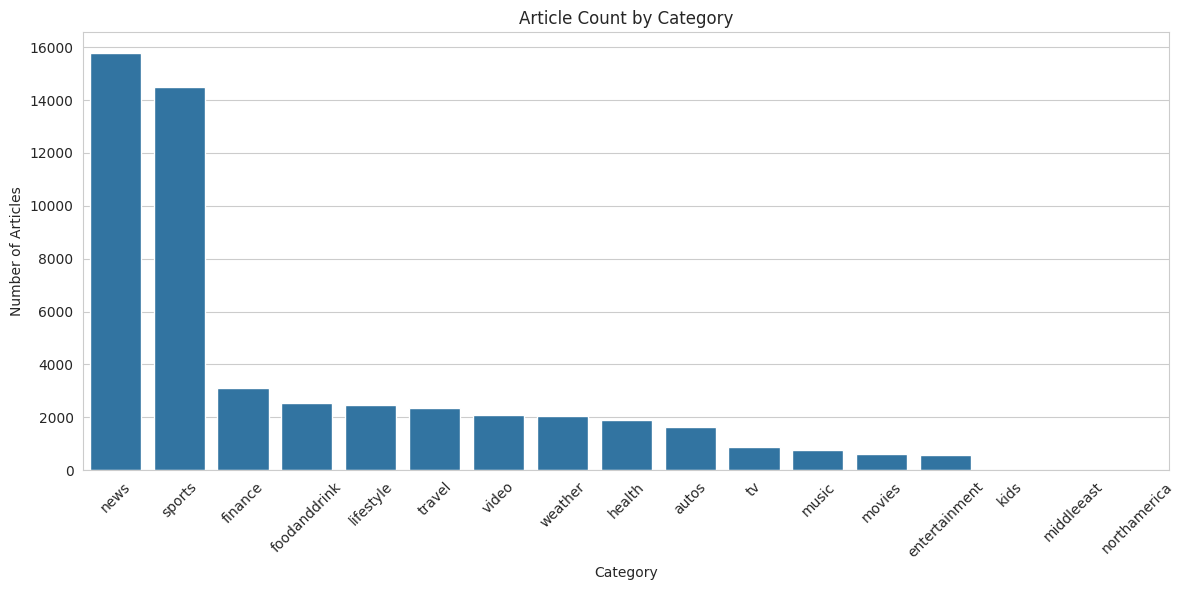

In [33]:
cat_counts = train_news['category'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=cat_counts.index, y=cat_counts.values)
plt.title('Article Count by Category')
plt.xlabel('Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/article_count_by_category.png")
plt.show()

The distribution of articles across categories is highly imbalanced, with news and sports dominating the dataset by a significant margin compared to other categories. In contrast, categories such as kids, middleeast, and northamerica are heavily underrepresented. This imbalance may bias recommendation models toward popular categories unless appropriate normalization or weighting techniques are applied.

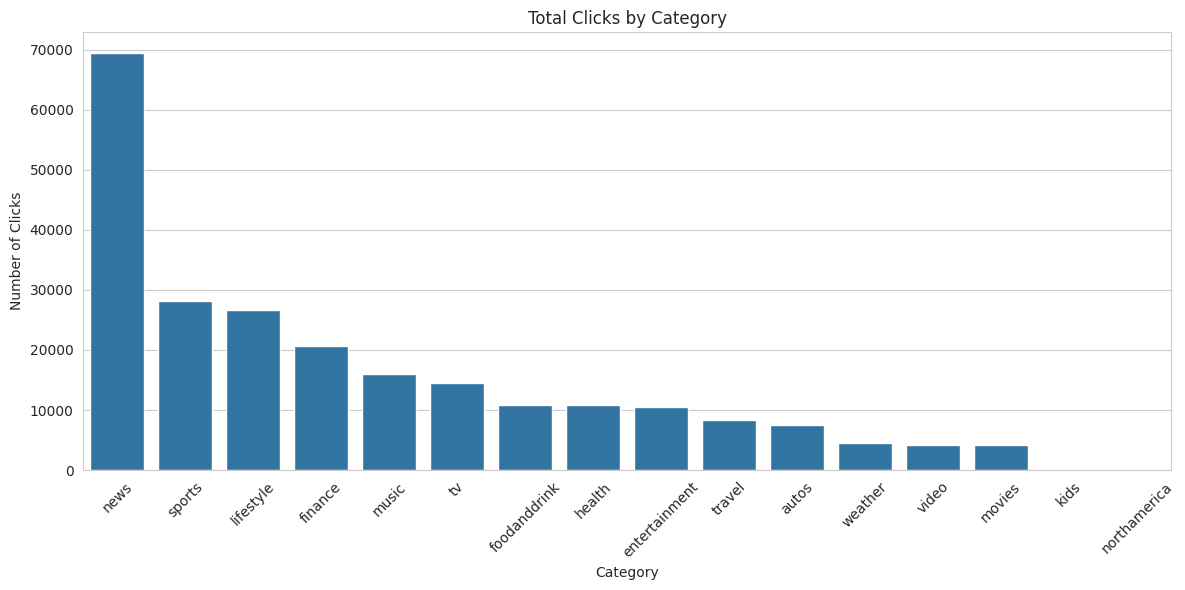

In [34]:
clicks_by_category = click_news.groupby('category')['clicked'].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=clicks_by_category.index, y=clicks_by_category.values)
plt.title('Total Clicks by Category')
plt.xlabel('Category')
plt.ylabel('Number of Clicks')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/clicks_by_category.png")
plt.show()

User click behavior is heavily concentrated in a few categories, with news receiving the highest number of clicks by a large margin, followed by sports and lifestyle. This indicates that user engagement aligns closely with the most prevalent content categories, reinforcing their dominance. In contrast, categories such as kids and northamerica receive minimal clicks, suggesting lower user interest or limited exposure.

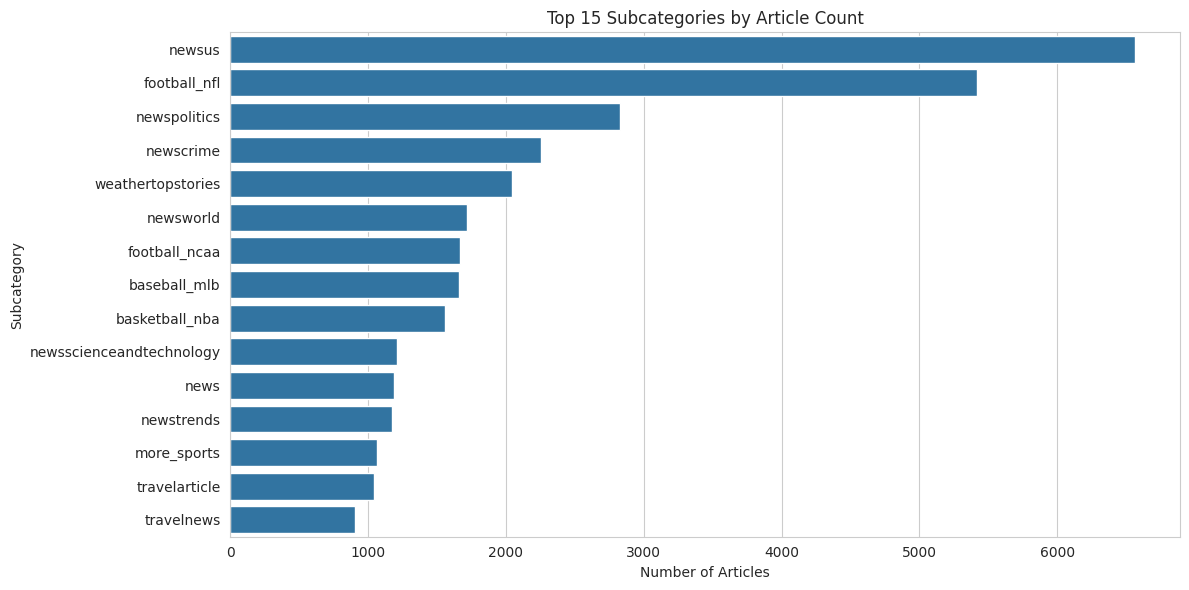

In [35]:
subcat_counts = train_news['subcategory'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=subcat_counts.values, y=subcat_counts.index)
plt.title('Top 15 Subcategories by Article Count')
plt.xlabel('Number of Articles')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/top15_subcategories.png")
plt.show()

Article distribution across subcategories is heavily skewed, with newsus and football_nfl accounting for a large share of the dataset. This suggests that content production is concentrated around a few high-interest topics, particularly news and sports. The presence of many smaller subcategories indicates a long-tail structure, which may challenge models to effectively learn from less-represented topics.

CTR per category:


,CTR
category,
music,0.059433
tv,0.059011
weather,0.051689
sports,0.047585
video,0.045464
news,0.043624
lifestyle,0.040559
finance,0.036476
health,0.035723


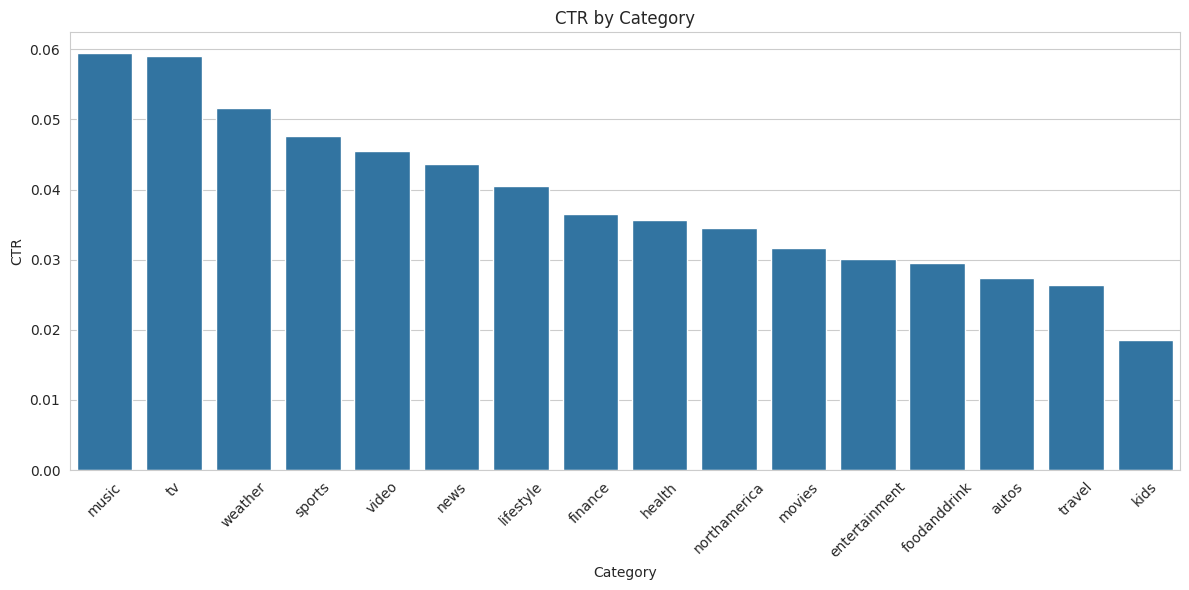

In [36]:
ctr_by_category = click_news.groupby('category')['clicked'].mean().sort_values(ascending=False)

print("CTR per category:")
display(ctr_by_category.to_frame("CTR"))

plt.figure(figsize=(12, 6))
sns.barplot(x=ctr_by_category.index, y=ctr_by_category.values)
plt.title('CTR by Category')
plt.xlabel('Category')
plt.ylabel('CTR')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/ctr_by_category.png")
plt.show()

Click-through rates vary noticeably across categories, with music and tv achieving the highest CTRs, indicating stronger user engagement relative to exposure. In contrast, categories such as kids, travel, and autos show lower CTRs, suggesting that users are less likely to interact with content in these areas. This highlights that user interest is not solely driven by content volume, but also by how engaging or relevant the category is to users.

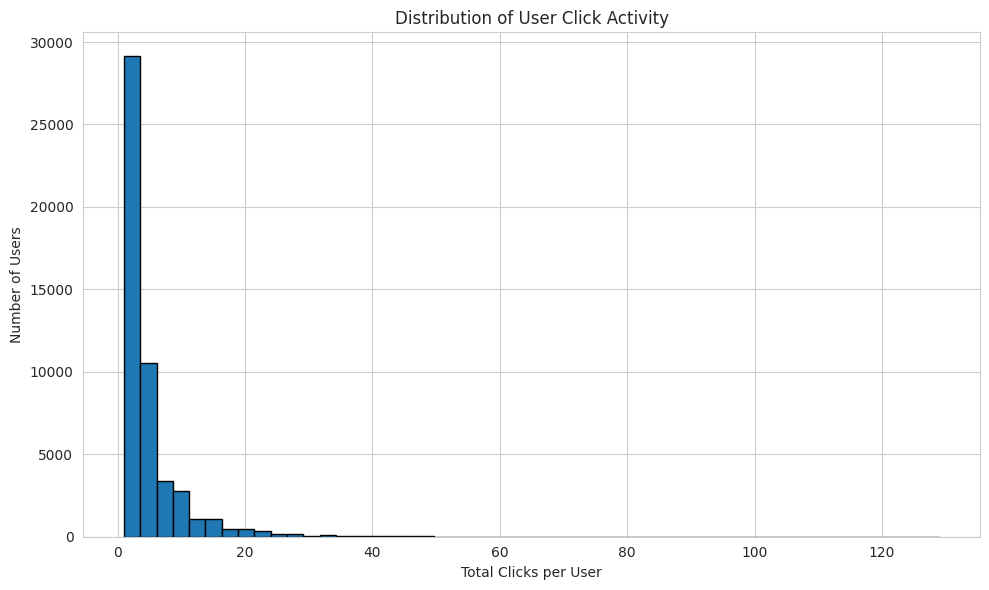

Percentage of users with fewer than 10 clicks: 88.33%


In [37]:
user_clicks = train_behaviors.groupby('user_id')['n_clicks'].sum()

plt.figure(figsize=(10, 6))
plt.hist(user_clicks, bins=50, edgecolor='black')
plt.title('Distribution of User Click Activity')
plt.xlabel('Total Clicks per User')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/user_click_distribution.png")
plt.show()

pct_under_10 = (user_clicks < 10).mean() * 100
print(f"Percentage of users with fewer than 10 clicks: {pct_under_10:.2f}%")

The distribution of user clicks is heavily right-skewed, with most users exhibiting minimal activity and a small subset acting as highly active users. With over 88% of users having fewer than 10 clicks, the dataset demonstrates strong sparsity in user interactions. This long-tail behavior highlights the need for recommendation models that can handle both sparse user data and highly active users effectively.

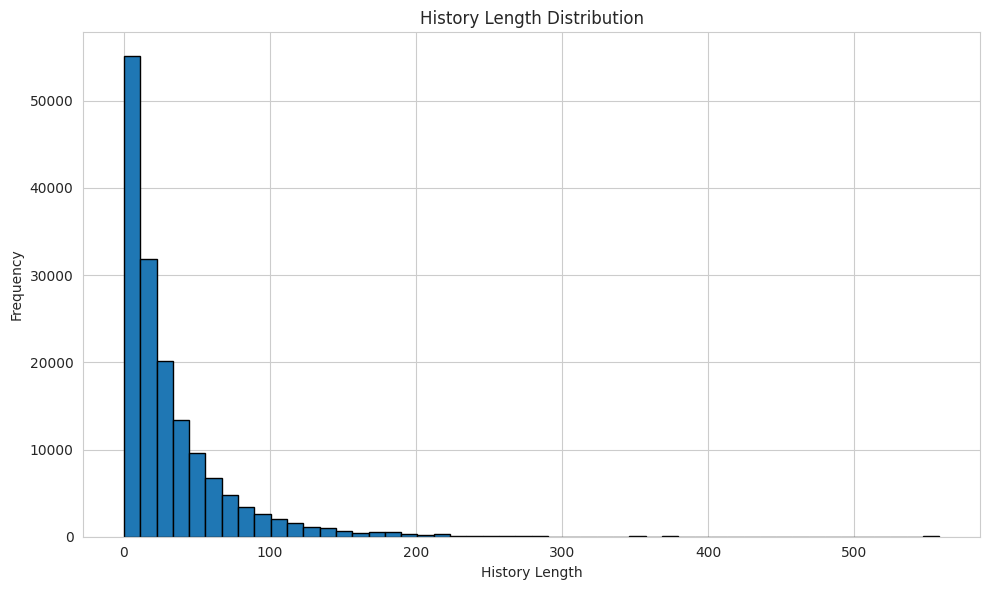

Mean history length: 32.54
Median history length: 19.00
90th percentile history length: 78.00


In [38]:
plt.figure(figsize=(10, 6))
plt.hist(train_behaviors['history_len'], bins=50, edgecolor='black')
plt.title('History Length Distribution')
plt.xlabel('History Length')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/history_length_distribution.png")
plt.show()

print(f"Mean history length: {train_behaviors['history_len'].mean():.2f}")
print(f"Median history length: {train_behaviors['history_len'].median():.2f}")
print(f"90th percentile history length: {train_behaviors['history_len'].quantile(0.9):.2f}")

The distribution of user history lengths is right-skewed, with most users having relatively short interaction histories while a small number have very long histories. The mean history length (32.54) is significantly higher than the median (19), indicating the presence of outliers with extensive activity. The 90th percentile at 78 further highlights that the majority of users have moderate history sizes, while a small subset contributes disproportionately large interaction histories.

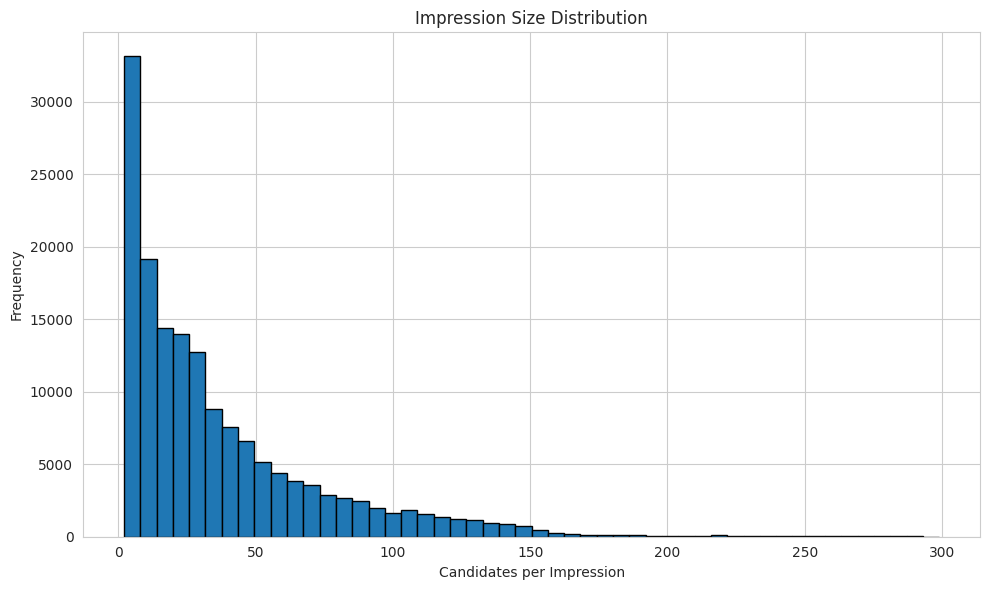

Average candidates per impression: 37.23
Fraction clicked: 0.0404


In [39]:
plt.figure(figsize=(10, 6))
plt.hist(train_behaviors['impression_size'], bins=50, edgecolor='black')
plt.title('Impression Size Distribution')
plt.xlabel('Candidates per Impression')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/impression_size_distribution.png")
plt.show()

print(f"Average candidates per impression: {train_behaviors['impression_size'].mean():.2f}")
print(f"Fraction clicked: {overall_ctr:.4f}")

The distribution of impression sizes is right-skewed, with most impressions containing a relatively small number of candidate articles, while a few impressions include a very large number. On average, each impression contains approximately 37.23 candidates, yet only a small fraction (CTR ≈ 4.04%) are clicked. This highlights the difficulty of the recommendation task, as models must accurately identify a few relevant items from a large pool of candidates.

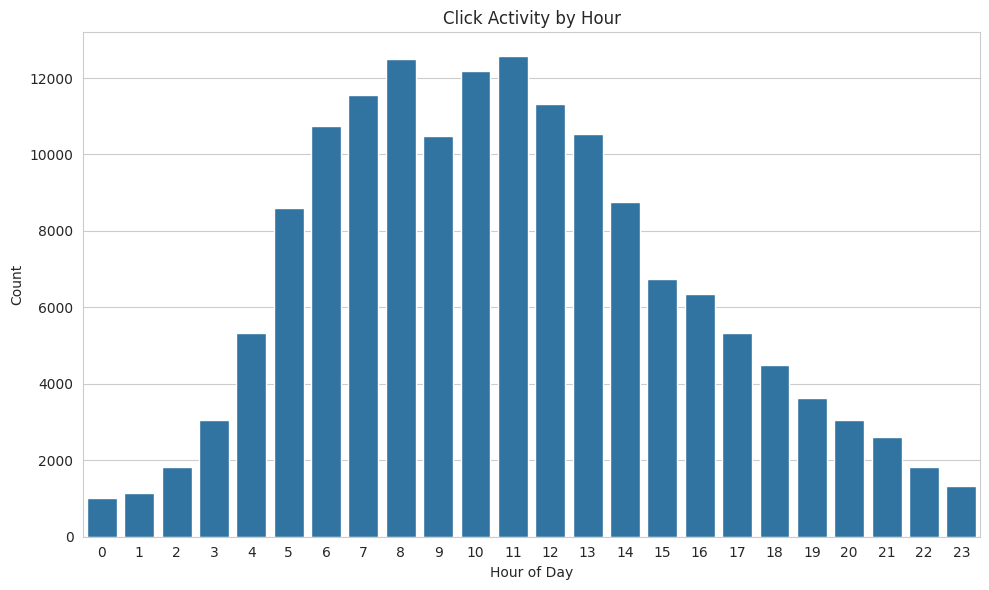

In [8]:
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=train_behaviors)
plt.title('Click Activity by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/click_activity_by_hour.png")
plt.show()

The hourly distribution of click activity reveals a strong diurnal pattern, with user engagement increasing sharply in the morning, peaking between 8 AM and 12 PM, and declining steadily afterward. Minimal activity during late-night hours suggests low user presence, while the midday peak reflects high engagement periods. These temporal patterns are important for recommendation systems, as incorporating time-based features could improve prediction accuracy by aligning recommendations with peak user activity periods.

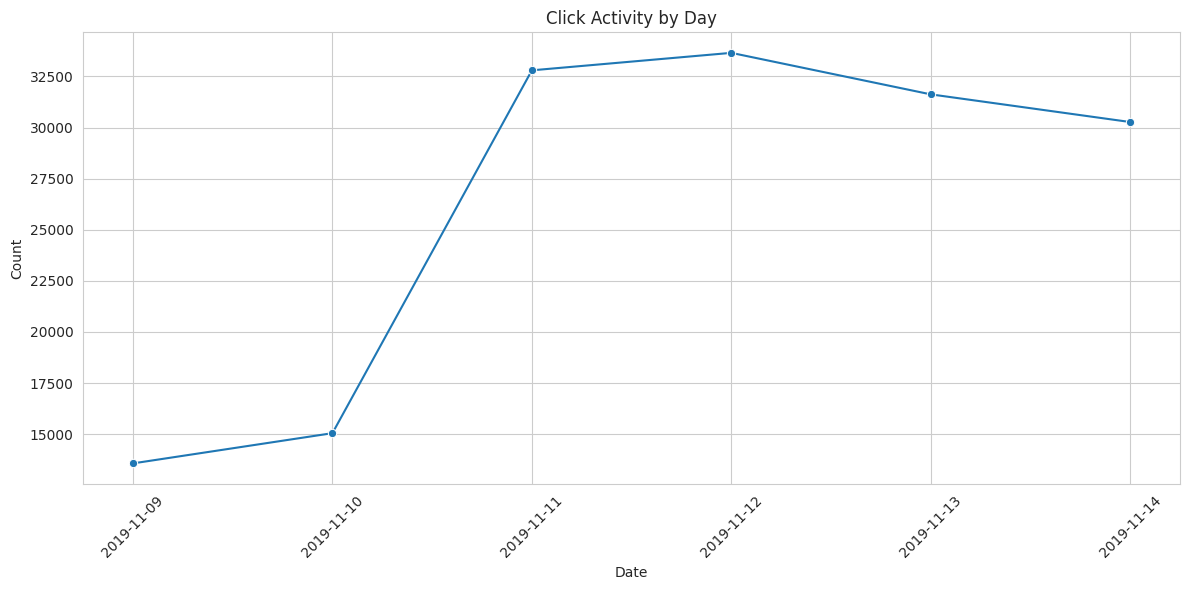

In [9]:
daily_counts = train_behaviors['date'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=daily_counts.index.astype(str), y=daily_counts.values, marker='o')
plt.title('Click Activity by Day')
plt.xlabel('Date')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/click_activity_by_day.png")
plt.show()

The daily click activity trend shows a sharp rise from November 9 to 11, followed by a peak on November 12 and a gradual decline. This indicates a temporal fluctuation in user engagement, possibly reflecting weekday vs. weekend behavior or content-driven spikes. Such variations highlight the importance of incorporating temporal dynamics into recommendation models to better capture changes in user activity over time.

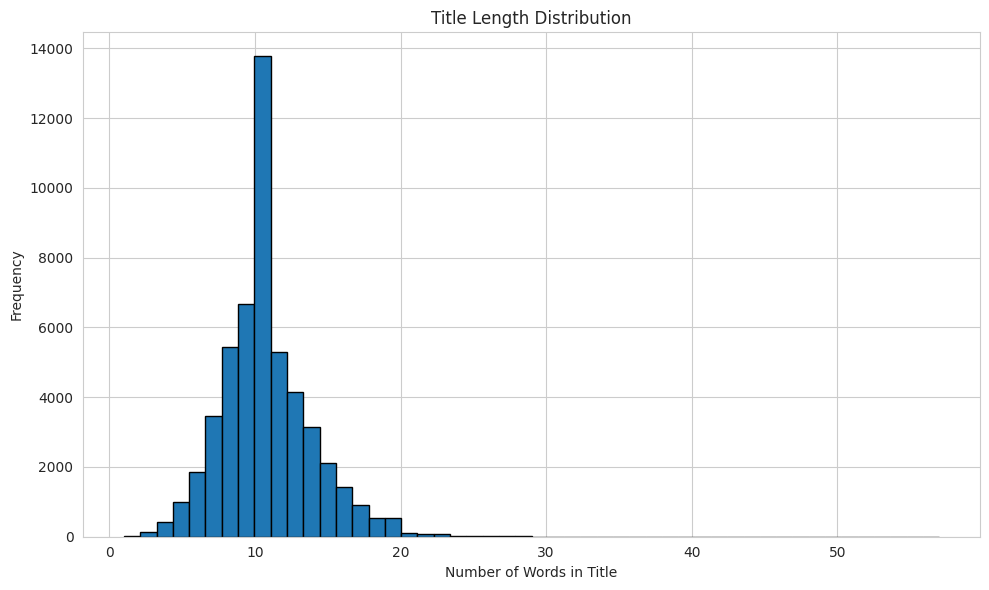

Average title length: 10.75


In [10]:
plt.figure(figsize=(10, 6))
plt.hist(train_news['title_len'], bins=50, edgecolor='black')
plt.title('Title Length Distribution')
plt.xlabel('Number of Words in Title')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/title_length_distribution.png")
plt.show()

print(f"Average title length: {train_news['title_len'].mean():.2f}")

The distribution of title lengths is approximately bell-shaped with an average title length of 10.75 words. Most article titles fall within a relatively narrow range (roughly 7–14 words), indicating a consistent editorial style. Very short and very long titles are less common, suggesting that titles are optimized to balance brevity and informativeness.

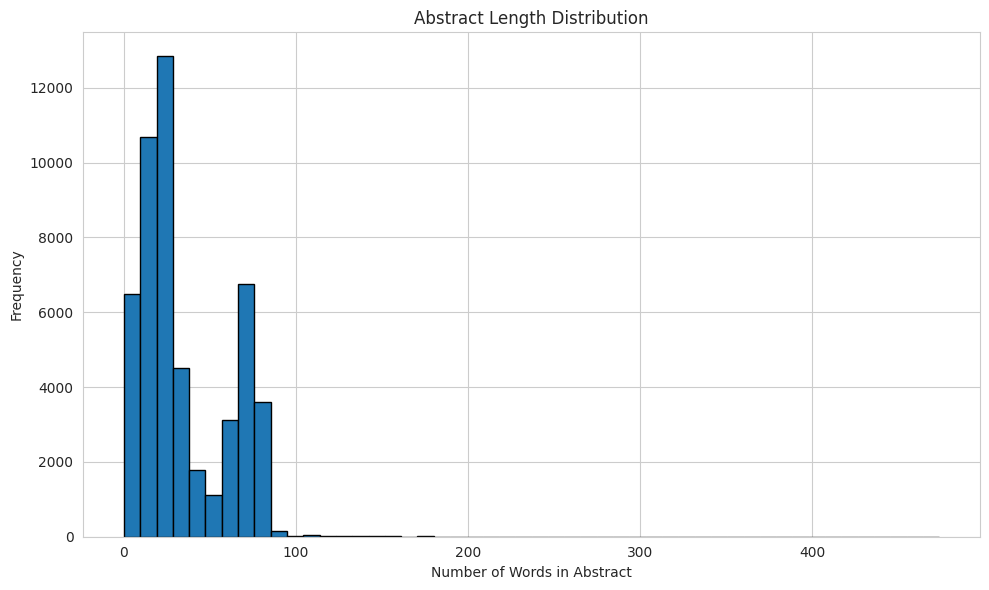

Average abstract length: 34.29


In [11]:
plt.figure(figsize=(10, 6))
plt.hist(train_news['abstract_len'], bins=50, edgecolor='black')
plt.title('Abstract Length Distribution')
plt.xlabel('Number of Words in Abstract')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/abstract_length_distribution.png")
plt.show()

print(f"Average abstract length: {train_news['abstract_len'].mean():.2f}")

The distribution of abstract lengths is right-skewed, with most abstracts being relatively short, while a smaller number extend to much longer lengths. The average abstract length is approximately 34.29 words, indicating that most articles provide concise summaries. However, the long tail suggests that some abstracts contain significantly more detailed descriptions.

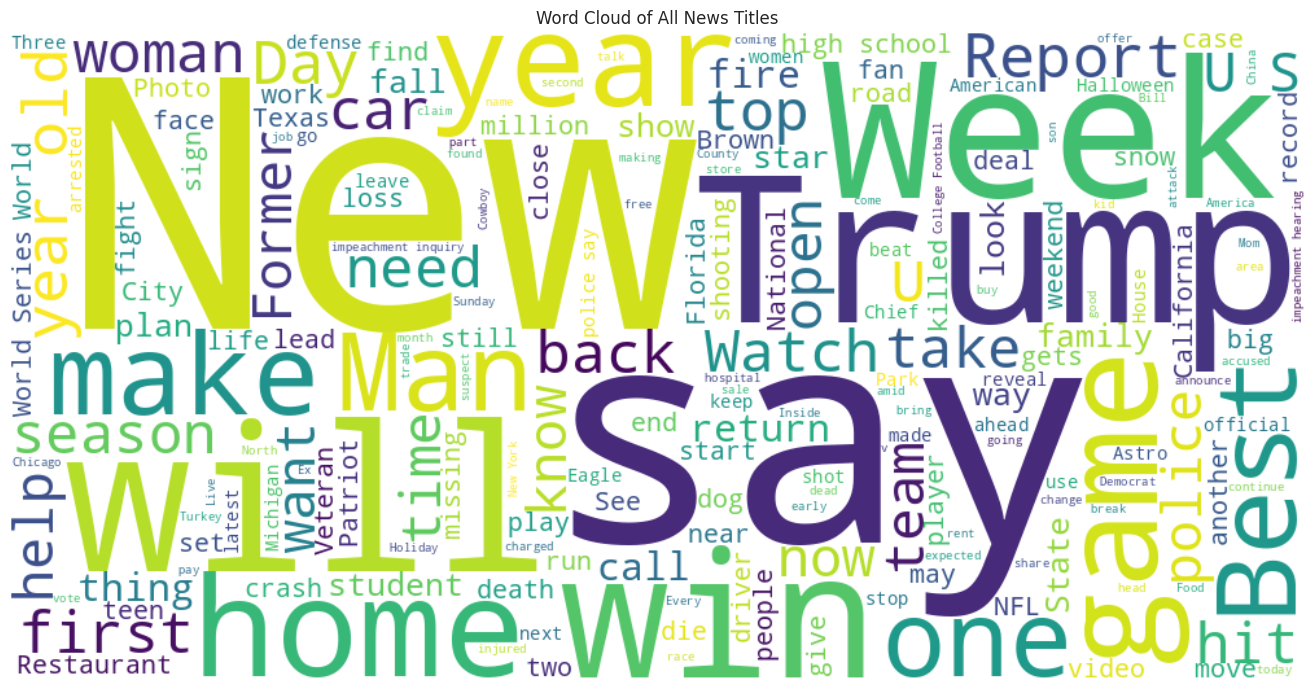

In [12]:
all_titles_text = " ".join(train_news['title'].dropna().astype(str))

wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_titles_text)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of All News Titles')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/wordcloud_all_titles.png")
plt.show()

The word cloud reveals that high-frequency terms are dominated by general news vocabulary and politically relevant keywords, with “trump” standing out as a central topic. Common verbs such as “say,” “make,” and “will” reflect a narrative-driven headline structure, emphasizing actions and statements. Additionally, the prevalence of broad terms like “news” and “week” suggests a mix of ongoing and time-sensitive content. These patterns indicate that textual features, particularly key entities and action words, could play a significant role in improving recommendation performance.

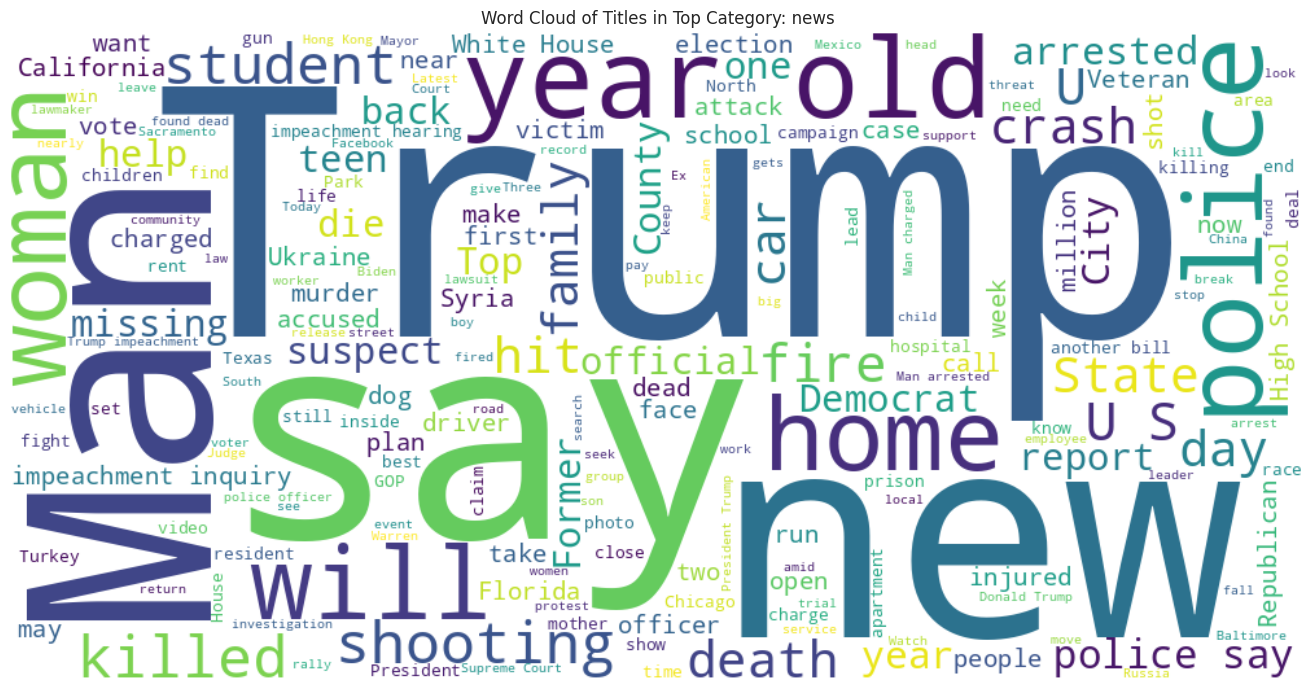

In [13]:
top_category = train_news['category'].value_counts().idxmax()

top_category_titles = " ".join(
    train_news.loc[train_news['category'] == top_category, 'title'].dropna().astype(str)
)

wordcloud_top = WordCloud(width=1000, height=500, background_color='white').generate(top_category_titles)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud_top, interpolation='bilinear')
plt.axis('off')
plt.title(f'Word Cloud of Titles in Top Category: {top_category}')
plt.tight_layout()
plt.savefig(f"{RESULTS_PATH}/wordcloud_top_category.png")
plt.show()

The word cloud for the top “news” category highlights a strong concentration of crime, politics, and public safety-related terms. Words such as “trump,” “say,” “police,” “killed,” “shooting,” and “suspect” appear prominently, indicating that a large portion of articles focus on crime reports, law enforcement, and political developments. The presence of geographic and institutional terms like “U.S.,” “State,” and “city” further suggests coverage centered on national and local events.